In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.layers import Input
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Cargar CIFAR-10
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Verificar dimensiones
print("Imagenes entrenamiento:", train_images.shape)
print("Etiquetas entrenamiento:", train_labels.shape)
print("Imagenes prueba:", test_images.shape)
print("Etiquetas prueba:", test_labels.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Imagenes entrenamiento: (50000, 32, 32, 3)
Etiquetas entrenamiento: (50000, 1)
Imagenes prueba: (10000, 32, 32, 3)
Etiquetas prueba: (10000, 1)


In [3]:
# Normalizar imágenes
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
#El shape de la primera imagen que se encuentra en la imagen de entrenamiento train_images
print(train_images[0].shape)

(32, 32, 3)


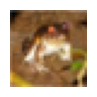

In [ ]:
plt.figure(figsize=(1,1))
plt.imshow(train_images[0])
plt.axis("off")
plt.show()

In [7]:
print(train_labels[0])

[6]


In [8]:
train_images[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [9]:
cardinalidad = len(np.unique(train_labels))
print(cardinalidad)

10


In [10]:
clases = ['avión', 'automóvil', 'pájaro','gato', 'ciervo', 'perro', 'rana', 'caballo', 'barco', 'camión o bus']

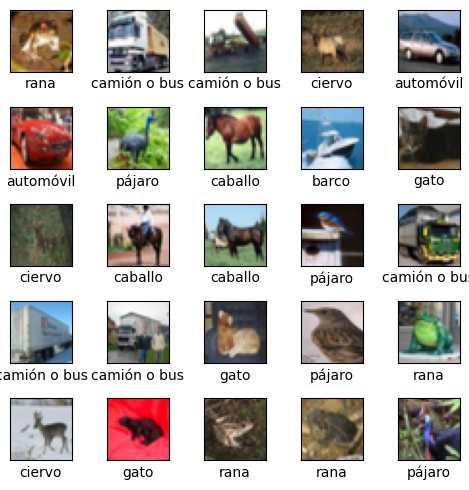

In [11]:
plt.figure(figsize=(5,5))

for i in range(25):
    plt.subplot(5, 5, i+1)
    plt.imshow(train_images[i])
    
    # Quitar grid y ticks
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    
    # Colocar nombre de la clase abajo
    plt.xlabel(clases[train_labels[i][0]])
    
plt.tight_layout()
plt.show()

In [16]:
filtros1 = 32
filtros2 = 16
filtros3 = 8
kernel_size = (3,3)
pool_size = (2,2)

neuronas1 = 64
neuronas2 = 32
clases_salida = 10

In [17]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

# Input
input_layer = Input(shape=(32, 32, 3))

# Convoluciones
x = Conv2D(filtros1, kernel_size, activation='relu')(input_layer)
x = MaxPooling2D(pool_size)(x)

x = Conv2D(filtros2, kernel_size, activation='relu')(x)
x = MaxPooling2D(pool_size)(x)

x = Conv2D(filtros3, kernel_size, activation='relu')(x)
x = MaxPooling2D(pool_size)(x)

# Red neuronal (Fully Connected)
x = Flatten()(x)
x = Dense(neuronas1, activation='relu')(x)
x = Dense(neuronas2, activation='relu')(x)
output_layer = Dense(clases_salida, activation='softmax')(x)

# Modelo
model = Model(inputs=input_layer, outputs=output_layer)

# Resumen
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 8)        │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,202 (43.76 KB)

 Trainable params: 11,202 (43.76 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer=Adam(),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [19]:
history = model.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_split=0.10
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.3448 - loss: 1.7698 - val_accuracy: 0.4372 - val_loss: 1.5314
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4578 - loss: 1.4796 - val_accuracy: 0.5016 - val_loss: 1.3791
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4928 - loss: 1.3898 - val_accuracy: 0.5044 - val_loss: 1.3638
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.5165 - loss: 1.3287 - val_accuracy: 0.5264 - val_loss: 1.3122
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5365 - loss: 1.2831 - val_accuracy: 0.5352 - val_loss: 1.2960
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5479 - loss: 1.2489 - val_accuracy: 0.5438 - val_loss: 1.2843
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5594 - loss: 1.2243 - val_accuracy: 0.5590 - val_loss: 1.2157
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5688 - loss: 1.1963 - val_accur

In [20]:
filtros1 = 64
filtros2 = 32
kernel_size = (3,3)
pool_size = (2,2)

neuronas = 64
clases_salida = 10

In [21]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.models import Model

input_layer = Input(shape=(32, 32, 3))

x = Conv2D(filtros1, kernel_size, activation='relu')(input_layer)
x = MaxPooling2D(pool_size)(x)

x = Conv2D(filtros2, kernel_size, activation='relu')(x)
x = MaxPooling2D(pool_size)(x)

x = Flatten()(x)
x = Dense(neuronas, activation='relu')(x)
output_layer = Dense(clases_salida)(x)

model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,698 (369.91 KB)

 Trainable params: 94,698 (369.91 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy

model.compile(
    optimizer=Adam(),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_images,
    train_labels,
    epochs=50,
    validation_split=0.10
)

Epoch 1/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4410 - loss: 1.5451 - val_accuracy: 0.5340 - val_loss: 1.3305
Epoch 2/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5688 - loss: 1.2173 - val_accuracy: 0.5940 - val_loss: 1.1675
Epoch 3/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6183 - loss: 1.0898 - val_accuracy: 0.6328 - val_loss: 1.0487
Epoch 4/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6460 - loss: 1.0099 - val_accuracy: 0.6432 - val_loss: 1.0180
Epoch 5/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6679 - loss: 0.9527 - val_accuracy: 0.6584 - val_loss: 0.9880
Epoch 6/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6847 - loss: 0.9012 - val_accuracy: 0.6500 - val_loss: 1.0065
Epoch 7/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7000 - loss: 0.8609 - val_accuracy: 0.6746 - val_loss: 0.9484
Epoch 8/50
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7110 - loss: 0.8234 -

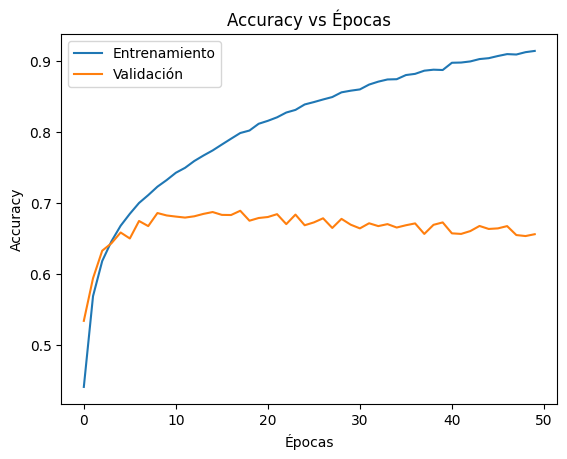

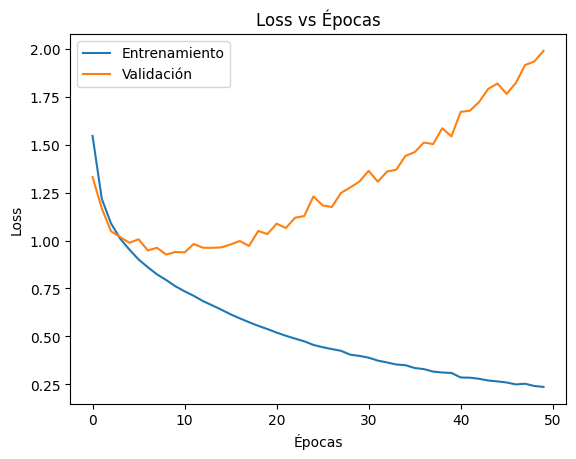

In [24]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend(['Entrenamiento', 'Validación'])
plt.title('Accuracy vs Épocas')
plt.show()

# Loss
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend(['Entrenamiento', 'Validación'])
plt.title('Loss vs Épocas')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


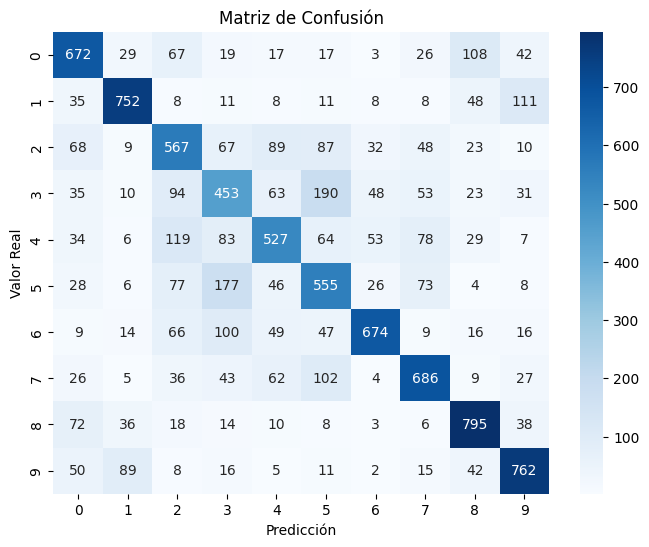

In [25]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Predicciones
predicciones = model.predict(test_images)
predicciones_clases = np.argmax(predicciones, axis=1)

# Etiquetas reales
y_true = test_labels.flatten()

# Matriz de confusión
cm = confusion_matrix(y_true, predicciones_clases)

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


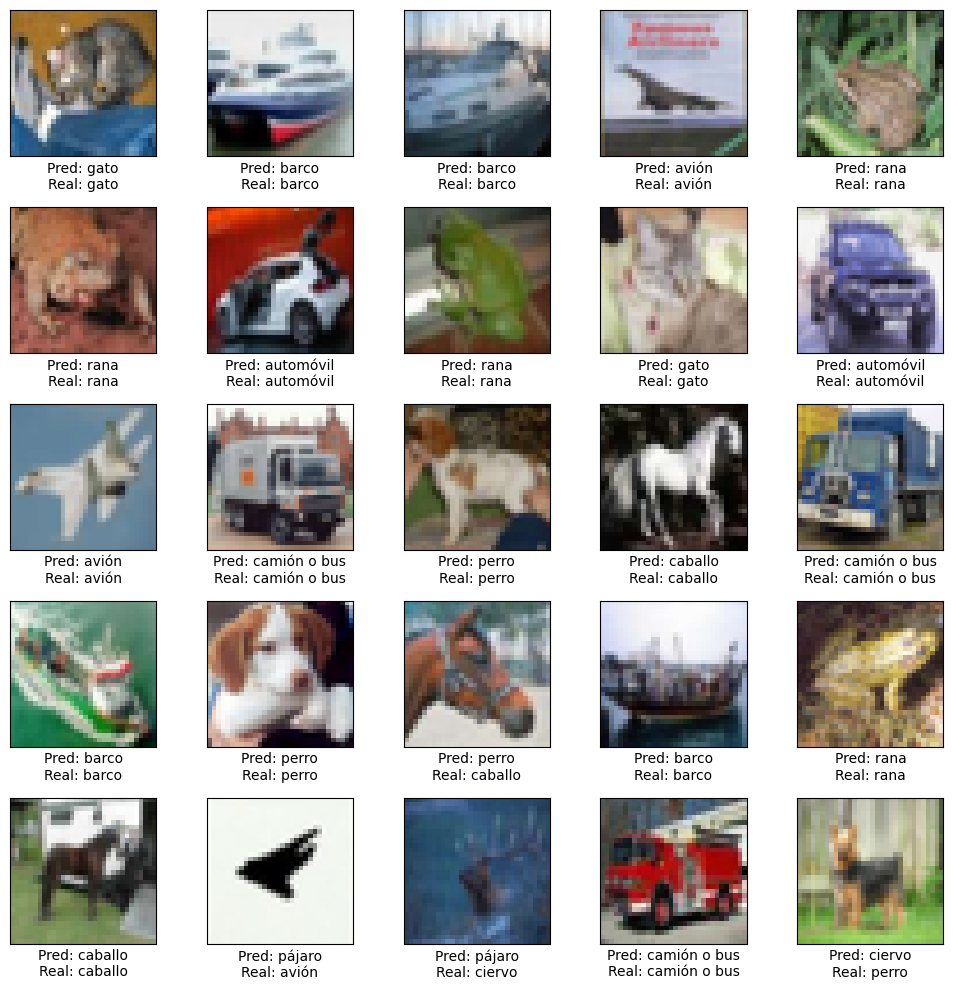

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Predicciones del modelo
predicciones = model.predict(test_images)
predicciones_clases = np.argmax(predicciones, axis=1)

# Etiquetas reales
y_true = test_labels.flatten()

# Nombres de clases
clases = ['avión', 'automóvil', 'pájaro','gato', 'ciervo',
          'perro', 'rana', 'caballo', 'barco', 'camión o bus']

plt.figure(figsize=(10,10))

for i in range(25):
    plt.subplot(5,5,i+1)
    plt.imshow(test_images[i])
    
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    
    # Etiqueta inferior con predicción y valor real
    plt.xlabel(
        "Pred: " + clases[predicciones_clases[i]] +
        "\nReal: " + clases[y_true[i]]
    )

plt.tight_layout()
plt.show()

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# URL de la imagen
url = 'https://esperanza.tur.ar/wp-content/uploads/2025/07/Sapo-Argentino-_1_.webp'

# Descargar imagen
response = requests.get(url)
img = Image.open(BytesIO(response.content))

# Mostrar imagen original
plt.figure()
plt.imshow(img)
plt.title("Imagen original")
plt.axis("off")
plt.show()

# Convertir a RGB por seguridad
img = img.convert('RGB')

# Redimensionar a 32x32
img_resized = img.resize((32, 32))

# Mostrar imagen redimensionada
plt.figure()
plt.imshow(img_resized)
plt.title("Imagen 32x32")
plt.axis("off")
plt.show()

# Convertir a arreglo numpy
img_array = np.array(img_resized)

# Normalizar igual que el entrenamiento
img_array = img_array / 255.0

# Ajustar forma para el modelo (1, 32, 32, 3)
img_array = img_array.reshape(1, 32, 32, 3)

print("Shape final:", img_array.shape)

UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x785b06ea62f0>

In [36]:
img_array = img_array / 255.0

In [37]:
import tensorflow as tf
import numpy as np

# Predicción (logits)
logits = model.predict(img_array)

# Aplicar softmax para obtener probabilidades
probabilidades = tf.nn.softmax(logits).numpy()

print("Vector de probabilidades:")
print(probabilidades)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Vector de probabilidades:
[[4.0966631e-07 8.6118423e-13 2.2347111e-03 6.2769100e-02 1.1865528e-05
  1.9506872e-09 5.1692681e-04 4.2947198e-07 9.3446654e-01 3.2962795e-16]]


In [40]:
clase_predicha = np.argmax(probabilidades)

clases = ['avión', 'automóvil', 'pájaro','gato', 'ciervo',
          'perro', 'rana', 'caballo', 'barco', 'camión o bus']

print("Clase predicha:", clases[clase_predicha])

Clase predicha: barco


In [39]:
# Ordenar probabilidades de mayor a menor
indices = np.argsort(probabilidades[0])[::-1]

print("\nProbabilidades por clase (ordenadas):\n")

for i in indices:
    print(clases[i], ":", probabilidades[0][i])


Probabilidades por clase (ordenadas):

barco : 0.93446654
gato : 0.0627691
pájaro : 0.002234711
rana : 0.0005169268
ciervo : 1.1865528e-05
caballo : 4.2947198e-07
avión : 4.096663e-07
perro : 1.9506872e-09
automóvil : 8.611842e-13
camión o bus : 3.2962795e-16
